# Chapter 06 Regression Splines: rendered figures

Executed preview for browsing on GitHub (static image output, since GitHub's notebook viewer cannot run the interactive JS the live book uses). The source of truth for regenerating the book's figures is `chapter-06-regression-splines-plots.py`. Run that script directly, not this notebook, to update `_generated/`.

Chapter 4 fit a straight line through payload size and checkout-API latency, and the line
worked: the relationship was close to linear across the range of payload sizes the service saw.

Concurrent request load is a different story. At low load, adding a few more simultaneous
requests barely moves latency. Past some point, the same increase in load produces a much
sharper rise, because the service is running out of capacity to process requests as fast as
they arrive. A straight line cannot represent both of those behaviors with one slope.

This chapter works through the tools that handle a curved relationship without abandoning
regression altogether:

1. *Why does a linear fit fail here, specifically?*
   The shape of the failure points directly at what kind of flexibility the model needs.
2. *Can a higher-degree polynomial just fix it?*
   Sometimes, but polynomials misbehave in a specific and predictable way near the edges of the
   data.
3. *What is a basis function, and why does almost every fix in this chapter use one?*
   Step functions, polynomials, and splines are all the same idea in different clothing.
4. *What is a regression spline, and how many knots does it need?*
   Piecewise polynomials joined smoothly at chosen points, with a meaningful trade-off in how
   many points to choose.
5. *What does a smoothing spline buy that a hand-placed knot cannot?*
   A penalty term, the same idea Chapter 4 used for Lasso and Ridge, applied to curve
   roughness instead of coefficient size.

In [1]:
import os
import numpy as np
import plotly.graph_objects as go
from scipy.interpolate import CubicSpline, LSQUnivariateSpline, UnivariateSpline

In [2]:
from IPython.display import Image

pio_width, pio_height = 760, 440

def show(fig: go.Figure, height: int = pio_height) -> Image:
    """Render a Plotly figure as a static PNG for the notebook preview
    (the live book embeds the interactive HTML version instead)."""
    return Image(fig.to_image(format="png", width=pio_width, height=height, scale=1))

## Setup

Random seed and helper functions shared by every figure in this chapter.

In [3]:
RNG = np.random.default_rng(7)

`saturation_curve` is a helper used by the figures below.

In [4]:
def saturation_curve(rho: np.ndarray, base_ms: float = 20.0) -> np.ndarray:
    """Mean latency under an M/M/1-style saturation curve as utilization rho -> 1."""
    return base_ms / (1.0 - rho)

`simulated_load_latency` is a helper used by the figures below.

In [5]:
def simulated_load_latency(n: int = 220, noise_scale: float = 3.0, seed: int | None = None):
    # A figure that fits an unstable estimator (a high-degree polynomial, a spline with
    # automatic knot selection) needs a data draw picked and checked for that specific
    # figure. Pulling from the shared module-level RNG makes that draw depend on how
    # many random numbers every earlier figure in this file happened to consume, so a
    # change to one figure shifts the data every figure after it sees, without either
    # figure's own code changing. Passing an explicit seed gives a figure its own fixed
    # draw, independent of that order.
    rng = RNG if seed is None else np.random.default_rng(seed)
    rho = np.sort(rng.uniform(0.05, 0.93, size=n))
    mean_latency = saturation_curve(rho)
    noise = rng.normal(0, noise_scale, size=n) * (1 + mean_latency / 40)
    latency = np.clip(mean_latency + noise, 1, None)
    return rho, latency

`squared_exponential_kernel` is a helper used by the figures below.

In [6]:
def squared_exponential_kernel(x1, x2, length_scale, variance=1.0):
    diff = x1[:, None] - x2[None, :]
    return variance * np.exp(-0.5 * (diff / length_scale) ** 2)

`gp_posterior` is a helper used by the figures below.

In [7]:
def gp_posterior(x_train, y_train, x_grid, length_scale, noise_var, variance=1.0):
    k_xx = squared_exponential_kernel(x_train, x_train, length_scale, variance)
    k_xx += noise_var * np.eye(len(x_train))
    k_xs = squared_exponential_kernel(x_train, x_grid, length_scale, variance)
    k_ss = squared_exponential_kernel(x_grid, x_grid, length_scale, variance)

    k_inv = np.linalg.inv(k_xx)
    mean = k_xs.T @ k_inv @ y_train
    cov = k_ss - k_xs.T @ k_inv @ k_xs
    std = np.sqrt(np.clip(np.diag(cov), 0, None))
    return mean, std

## Why a straight line breaks down: concurrent load and latency

An OLS line captures the general upward trend but misses both ends: it underpredicts latency at low load, dipping toward zero while observed latency holds near 20 ms, then overshoots badly as load climbs toward the top of the range shown, precisely the region where an accurate prediction matters most for an alerting threshold.

In [8]:
def fig_linear_misfit() -> go.Figure:
    ranges = [(0.05, 0.93), (0.05, 0.75), (0.05, 0.5)]
    frames = []
    for lo, hi in ranges:
        rho, latency = simulated_load_latency(n=200)
        mask = (rho >= lo) & (rho <= hi)
        rho_r, lat_r = rho[mask], latency[mask]
        coef = np.polyfit(rho_r, lat_r, deg=1)
        grid = np.linspace(lo, hi, 100)
        fit = np.polyval(coef, grid)
        true_curve = saturation_curve(grid)
        frames.append(
            go.Frame(
                name=f"{lo:.2f}-{hi:.2f}",
                data=[
                    go.Scatter(x=rho_r, y=lat_r, mode="markers", name="observed",
                               marker=dict(color="#B7C7DB", size=6, opacity=0.6)),
                    go.Scatter(x=grid, y=true_curve, mode="lines", name="true saturation curve",
                               line=dict(color="#54A24B", width=2, dash="dot")),
                    go.Scatter(x=grid, y=fit, mode="lines", name="OLS line",
                               line=dict(color="#E45756", width=3)),
                ],
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames)
    fig.update_layout(
        title="An OLS line forced through a saturating load-latency curve",
        xaxis_title="Utilization (rho)",
        yaxis_title="Latency (ms)",
        yaxis_range=[0, 400],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "Utilization range shown: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

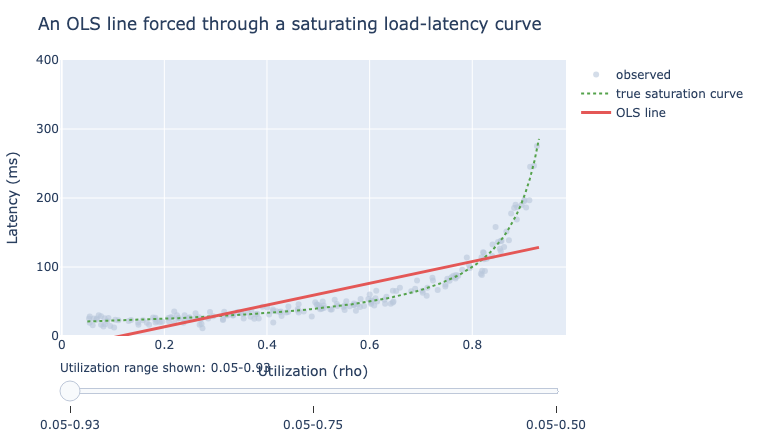

In [9]:
show(fig_linear_misfit())

## Polynomial regression and its instability at the edges

The fit improves through degree 4 to 6, tracking the saturation curve closely, then starts wobbling through the middle of the range and swinging near the high-load boundary as degree keeps rising: the Runge phenomenon in practice, worst in precisely the region an operator cares about most.

In [10]:
def fig_poly_degree() -> go.Figure:
    # A dense sample (n in the hundreds) gives least-squares polynomial regression enough
    # data to stay well-behaved even at degree 12, which hides the Runge phenomenon the
    # section is about. A smaller sample forces a high-degree fit closer to interpolating
    # the individual points, which is what makes the boundary oscillation show up.
    rho, latency = simulated_load_latency(n=35, noise_scale=2.5, seed=7)
    grid = np.linspace(rho.min(), rho.max(), 300)
    true_curve = saturation_curve(grid)
    degrees = [2, 4, 6, 9, 14]
    frames = []
    for deg in degrees:
        coef = np.polyfit(rho, latency, deg=deg)
        fit = np.polyval(coef, grid)
        frames.append(
            go.Frame(
                name=str(deg),
                data=[
                    go.Scatter(x=rho, y=latency, mode="markers", name="observed",
                               marker=dict(color="#B7C7DB", size=6, opacity=0.6)),
                    go.Scatter(x=grid, y=true_curve, mode="lines", name="true curve",
                               line=dict(color="#54A24B", width=2, dash="dot")),
                    go.Scatter(x=grid, y=fit, mode="lines", name=f"degree {deg} fit",
                               line=dict(color="#E45756", width=3)),
                ],
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames)
    fig.update_layout(
        title="Polynomial regression degree vs. the Runge phenomenon",
        xaxis_title="Utilization (rho)",
        yaxis_title="Latency (ms)",
        yaxis_range=[-50, 500],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "Polynomial degree: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

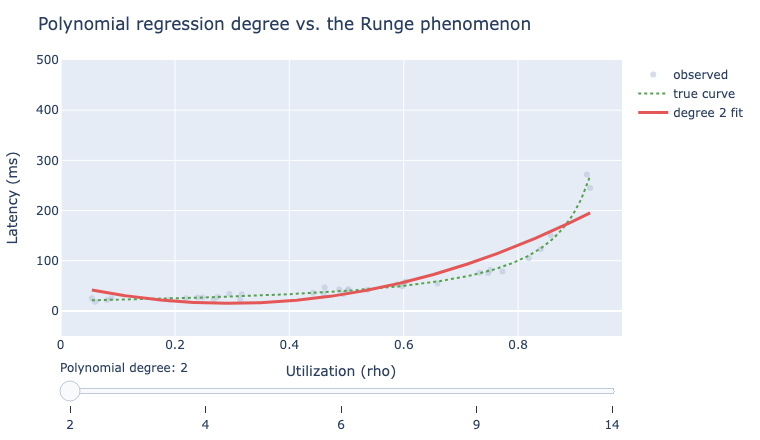

In [11]:
show(fig_poly_degree())

## Basis functions: the idea underneath every fix in this chapter

The polynomial basis grows without bound and covers the whole range at once, so a change anywhere reshapes the curve everywhere. The step-function basis is hard-edged flat boxes, and the cubic spline basis is smooth, overlapping bumps, each nonzero over only part of the range, the property that lets a spline bend locally without disturbing the fit elsewhere.

In [12]:
def fig_basis_functions() -> go.Figure:
    grid = np.linspace(0, 1, 300)
    families = ["Polynomial (degree 0-3)", "Step functions (4 regions)",
                "Cubic spline (3 interior knots)"]
    frames = []

    # Polynomial basis: 1, x, x^2, x^3
    poly_curves = [grid ** k for k in range(4)]
    poly_names = ["b0(x) = 1", "b1(x) = x", "b2(x) = x^2", "b3(x) = x^3"]

    # Step-function basis: four indicator regions
    cuts = [0.0, 0.25, 0.5, 0.75, 1.0]
    step_curves = []
    step_names = []
    for i in range(4):
        curve = ((grid >= cuts[i]) & (grid < cuts[i + 1] if i < 3 else grid <= cuts[i + 1])).astype(float)
        step_curves.append(curve)
        step_names.append(f"indicator[{cuts[i]:.2f} <= x < {cuts[i+1]:.2f}]")

    # Cubic spline basis via B-splines with 3 interior knots
    from scipy.interpolate import BSpline
    interior_knots = [0.25, 0.5, 0.75]
    degree = 3
    knots = np.concatenate([[0] * (degree + 1), interior_knots, [1] * (degree + 1)])
    n_basis = len(knots) - degree - 1
    spline_curves = []
    spline_names = []
    for i in range(n_basis):
        coeffs = np.zeros(n_basis)
        coeffs[i] = 1.0
        b = BSpline(knots, coeffs, degree, extrapolate=False)
        curve = np.nan_to_num(b(grid))
        spline_curves.append(curve)
        spline_names.append(f"B-spline basis {i + 1}")

    colors = ["#4C78A8", "#E45756", "#54A24B", "#F58518", "#B279A2", "#72B7B2", "#FF9DA6"]

    for name, curves, curve_names in [
        (families[0], poly_curves, poly_names),
        (families[1], step_curves, step_names),
        (families[2], spline_curves, spline_names),
    ]:
        traces = [
            go.Scatter(x=grid, y=curve, mode="lines", name=cname,
                       line=dict(color=colors[i % len(colors)], width=3))
            for i, (curve, cname) in enumerate(zip(curves, curve_names))
        ]
        frames.append(go.Frame(name=name, data=traces))

    # Short display labels on purpose: the full frame names ("Polynomial (degree 0-3)",
    # "Cubic spline (3 interior knots)") overhang past the plot margins at the slider's
    # end positions and get clipped by the plot boundary. Frame names stay unchanged
    # below since the animate() call targets them by name; the currentvalue prefix plus
    # short label still identifies the family unambiguously.
    short_labels = ["Polynomial", "Step functions", "Cubic spline"]

    fig = go.Figure(data=frames[0].data, frames=frames)
    fig.update_layout(
        title="Every fix in this chapter is a linear model on a different set of basis "
              "functions",
        xaxis_title="x (normalized utilization)",
        yaxis_title="b_k(x)",
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "Basis function family: "},
            "steps": [
                {"label": label, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f, label in zip(frames, short_labels)
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

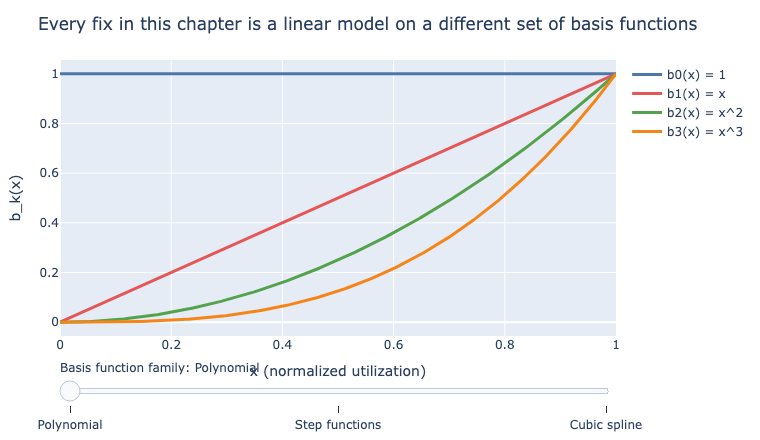

In [13]:
show(fig_basis_functions())

## Regression splines: piecewise polynomials joined at knots

Three or four knots track the saturation curve well; a dozen knots start chasing noise between individual points, the same overfitting pattern a high-degree polynomial shows, without the boundary oscillation.

In [14]:
def fig_knot_count() -> go.Figure:
    # As with fig_poly_degree, a large sample gives the spline enough data that even 12
    # knots stays smooth, which hides the overfitting this figure is meant to show. A
    # smaller sample makes 12 knots visibly start chasing individual points.
    rho, latency = simulated_load_latency(n=45, noise_scale=2.5, seed=7)
    grid = np.linspace(rho.min() + 0.01, rho.max() - 0.01, 300)
    true_curve = saturation_curve(grid)
    knot_counts = [2, 4, 8, 12]
    frames = []
    for k in knot_counts:
        interior_knots = np.linspace(rho.min(), rho.max(), k + 2)[1:-1]
        spline = LSQUnivariateSpline(rho, latency, t=interior_knots, k=3)
        fit = spline(grid)
        frames.append(
            go.Frame(
                name=str(k),
                data=[
                    go.Scatter(x=rho, y=latency, mode="markers", name="observed",
                               marker=dict(color="#B7C7DB", size=6, opacity=0.6)),
                    go.Scatter(x=grid, y=true_curve, mode="lines", name="true curve",
                               line=dict(color="#54A24B", width=2, dash="dot")),
                    go.Scatter(x=grid, y=fit, mode="lines", name=f"{k}-knot cubic spline",
                               line=dict(color="#E45756", width=3)),
                ],
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames)
    fig.update_layout(
        title="A cubic regression spline as the number of interior knots grows",
        xaxis_title="Utilization (rho)",
        yaxis_title="Latency (ms)",
        yaxis_range=[-20, 400],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "Interior knots: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

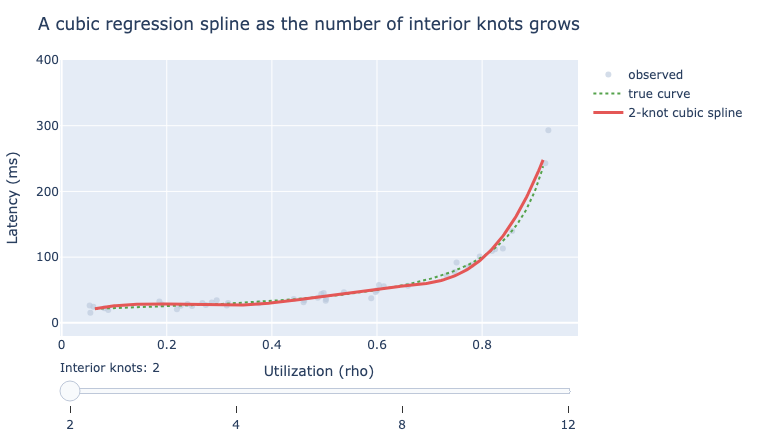

In [15]:
show(fig_knot_count())

## Natural cubic splines: constraining the boundaries

Both curves are fit to the same knots and agree everywhere the data covers. Past the last knot, the unconstrained cubic spline keeps curving on its own terms; the natural cubic spline continues in a straight line instead, matching the value and slope it held at the boundary.

In [16]:
def fig_natural_boundary() -> go.Figure:
    rho, latency = simulated_load_latency(n=60, noise_scale=2.0, seed=7)
    cutoff = 0.85
    mask = rho <= cutoff
    rho_obs, lat_obs = rho[mask], latency[mask]

    # Fit a smooth curve to the observed data, then read off its value at four knot
    # positions. Both the unconstrained and the natural spline below pass through the
    # same four points, so the two curves agree everywhere between the first and last
    # knot; the comparison isolates what each does past the last one, where no
    # observation exists yet.
    interior_knots = np.quantile(rho_obs, [0.25, 0.5, 0.75])
    smoothed = LSQUnivariateSpline(rho_obs, lat_obs, t=interior_knots, k=3)
    knot_xs = np.concatenate([[rho_obs.min()], interior_knots, [rho_obs.max()]])
    knot_ys = smoothed(knot_xs)

    unconstrained = CubicSpline(knot_xs, knot_ys, bc_type="not-a-knot", extrapolate=True)
    natural = CubicSpline(knot_xs, knot_ys, bc_type="natural")

    grid = np.linspace(rho.min(), rho.max(), 300)
    true_curve = saturation_curve(grid)
    unconstrained_curve = unconstrained(grid)

    # A natural cubic spline is linear beyond its boundary knots by definition, not
    # merely a cubic segment whose curvature happens to be small there. Splicing in a
    # straight line, anchored to the natural fit's own value and slope at the last
    # knot, is what makes that definition visible past the boundary.
    right_slope = natural(knot_xs[-1], 1)
    right_val = natural(knot_xs[-1])
    inside = grid <= knot_xs[-1]
    natural_curve = np.where(
        inside,
        natural(np.clip(grid, knot_xs[0], knot_xs[-1])),
        right_val + right_slope * (grid - knot_xs[-1]),
    )

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=rho_obs, y=lat_obs, mode="markers", name="observed so far",
                              marker=dict(color="#B7C7DB", size=6, opacity=0.7)))
    fig.add_trace(go.Scatter(x=grid, y=true_curve, mode="lines", name="true curve",
                              line=dict(color="#54A24B", width=2, dash="dot")))
    fig.add_trace(go.Scatter(x=grid, y=unconstrained_curve, mode="lines",
                              name="unconstrained cubic spline",
                              line=dict(color="#E45756", width=3)))
    fig.add_trace(go.Scatter(x=grid, y=natural_curve, mode="lines",
                              name="natural cubic spline",
                              line=dict(color="#4C78A8", width=3)))
    fig.add_vline(x=cutoff, line=dict(color="#888888", dash="dot"),
                  annotation_text="last observed knot", annotation_position="top left")
    fig.update_layout(
        title="Past the last knot: an unconstrained cubic spline vs. a natural cubic spline",
        xaxis_title="Utilization (rho)",
        yaxis_title="Latency (ms)",
        yaxis_range=[-20, 300],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

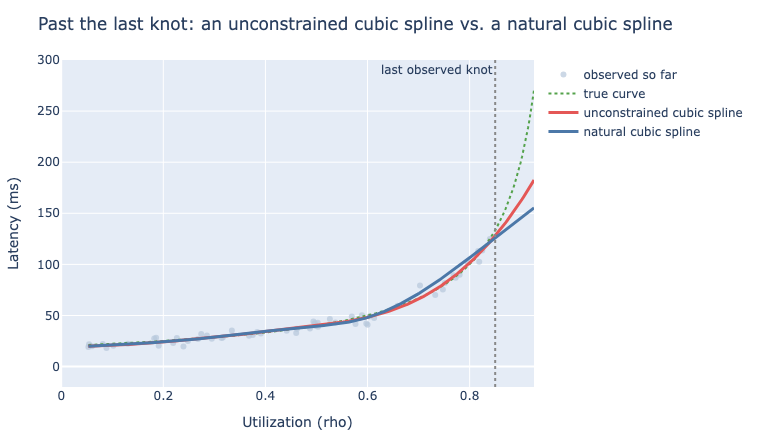

In [17]:
show(fig_natural_boundary())

## Smoothing splines: a penalty instead of a knot count

A small lambda produces a wiggly curve that chases individual points, and a large lambda flattens the fit back toward a straight line, recovering something close to the OLS fit that opened this chapter.

In [18]:
def fig_smoothing_lambda() -> go.Figure:
    # scipy's UnivariateSpline knot-selection becomes numerically unstable at n=220 for
    # several of the s values below (fit values spike into the thousands rather than
    # tracking the data), which is a fitting artifact rather than the roughness-penalty
    # story this figure exists to tell. A smaller sample and a re-tuned multiplier list
    # keep every step numerically well-behaved while still tracing the same path from a
    # wiggly, near-interpolating fit at small s to a near-straight line at large s.
    rho, latency = simulated_load_latency(n=70, noise_scale=2.5, seed=7)
    grid = np.linspace(rho.min(), rho.max(), 300)
    true_curve = saturation_curve(grid)
    n = len(rho)
    s_multipliers = [0.02, 0.5, 2.5, 6.0, 20.0]
    frames = []
    for mult in s_multipliers:
        s_value = mult * n
        spline = UnivariateSpline(rho, latency, s=s_value, k=3)
        fit = spline(grid)
        frames.append(
            go.Frame(
                name=f"{mult:.2f}",
                data=[
                    go.Scatter(x=rho, y=latency, mode="markers", name="observed",
                               marker=dict(color="#B7C7DB", size=6, opacity=0.6)),
                    go.Scatter(x=grid, y=true_curve, mode="lines", name="true curve",
                               line=dict(color="#54A24B", width=2, dash="dot")),
                    go.Scatter(x=grid, y=fit, mode="lines", name="smoothing spline",
                               line=dict(color="#E45756", width=3)),
                ],
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames)
    fig.update_layout(
        title="Smoothing spline fit as the roughness penalty increases",
        xaxis_title="Utilization (rho)",
        yaxis_title="Latency (ms)",
        yaxis_range=[-20, 400],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "Relative penalty strength: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

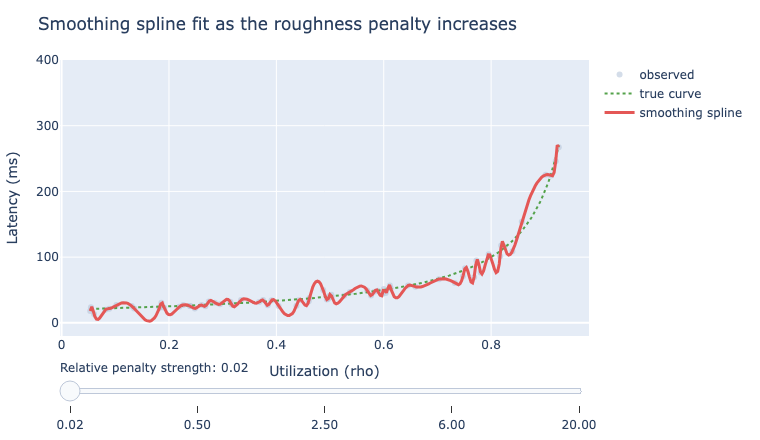

In [19]:
show(fig_smoothing_lambda())

## A Bayesian perspective

The credible band widens noticeably at the high-load edge, where observations are sparser, an honest signal that the model is least certain in the region that matters most, something a single fitted spline curve cannot say about itself.

In [20]:
def fig_gp_posterior() -> go.Figure:
    rho, latency = simulated_load_latency(n=60, noise_scale=2.5, seed=7)
    y_mean, y_std = latency.mean(), latency.std()
    y_norm = (latency - y_mean) / y_std
    # The grid used to stop at rho.max(), the single highest observed point, so the
    # credible band was narrowest at the plot's right edge, since that pixel sat on top
    # of an observation. Extending the grid a short distance past the last observed
    # point is what shows the band widening in a region with no nearby data, the
    # behavior the prose below describes.
    grid = np.linspace(rho.min(), 0.95, 150)
    true_curve = saturation_curve(grid)

    length_scales = [0.03, 0.08, 0.2, 0.5]
    frames = []
    for ls in length_scales:
        mean_norm, std_norm = gp_posterior(rho, y_norm, grid, length_scale=ls, noise_var=0.05)
        mean = mean_norm * y_std + y_mean
        std = std_norm * y_std
        upper = mean + 1.96 * std
        lower = mean - 1.96 * std
        frames.append(
            go.Frame(
                name=f"{ls:.2f}",
                data=[
                    go.Scatter(x=np.concatenate([grid, grid[::-1]]),
                               y=np.concatenate([upper, lower[::-1]]),
                               fill="toself", fillcolor="rgba(228,87,86,0.2)",
                               line=dict(color="rgba(255,255,255,0)"),
                               name="95% credible band", showlegend=True),
                    go.Scatter(x=rho, y=latency, mode="markers", name="observed",
                               marker=dict(color="#B7C7DB", size=6, opacity=0.7)),
                    go.Scatter(x=grid, y=true_curve, mode="lines", name="true curve",
                               line=dict(color="#54A24B", width=2, dash="dot")),
                    go.Scatter(x=grid, y=mean, mode="lines", name="GP posterior mean",
                               line=dict(color="#E45756", width=3)),
                ],
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames)
    fig.update_layout(
        title="Gaussian process posterior mean and credible band at varying length-scales",
        xaxis_title="Utilization (rho)",
        yaxis_title="Latency (ms)",
        yaxis_range=[-50, 450],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "Kernel length-scale: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

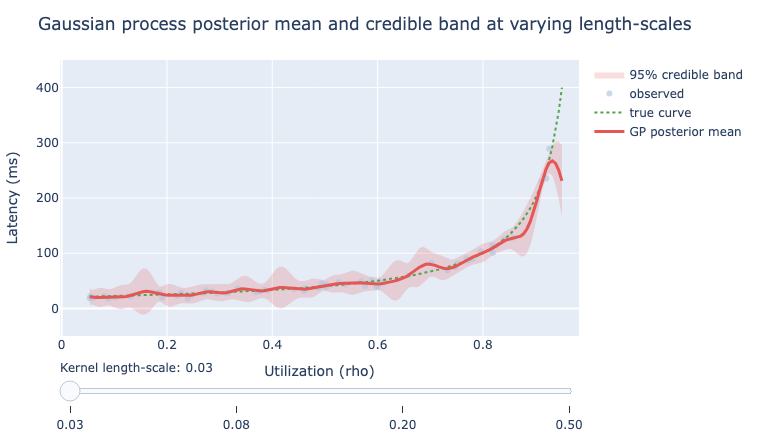

In [21]:
show(fig_gp_posterior())